# Global Job Market & Skills Analytics

**IBM SkillsBuild Data Analytics with AI — Academic Internship Program 2026**
*(BharatCares, in association with AICTE)*

**Author:** Akash V Hiremath


## 1. Project Introduction

The global technology and data-science hiring market changes quickly, and students and job seekers often struggle
to know which skills, roles, and locations are actually associated with demand and compensation, as opposed to
what is simply popular on social media. This project applies a complete data-analytics workflow — cleaning,
exploratory analysis, statistics, SQL-style querying, visualization, and a small supervised-learning component —
to a real, publicly available dataset of job postings, in order to produce evidence-based (not assumed) findings.


## 2. Problem Statement

It is difficult for students, job seekers, and educational institutions to know which specific skills, tools,
seniority levels, and locations are associated with hiring demand and higher pay in the data-science job market.
This project analyzes a real dataset of data-science-related job postings to identify measurable patterns in
skill demand, job-role distribution, salary, seniority, and geography — and to test, with basic statistics,
whether these patterns are meaningful rather than coincidental.

**Important scope note:** the selected dataset (see Section 4) covers **United States, data-science-related job
postings collected in 2020**. It is not a live, multi-country, all-industries feed. All findings in this notebook
describe patterns *within this dataset* — they are not a claim about the entire global job market at all times.


## 3. Objectives

1. Load and inspect a real job-postings dataset — verify which fields actually exist before analyzing them.
2. Clean the dataset (duplicates, missing values, inconsistent categories) and document every decision.
3. Extract a structured skills taxonomy from free-text job descriptions.
4. Identify the most in-demand skills, overall and by job role.
5. Analyze salary by job role, seniority, and location (all present in this dataset).
6. Apply basic statistical tests (ANOVA, Pearson correlation, t-tests) to check whether these relationships are
   statistically meaningful, without claiming causation.
7. Build a small, transparent salary-prediction model (Random Forest) as the AI/ML component, and honestly report
   its accuracy and limitations.
8. Summarize actionable, appropriately-hedged recommendations for students, institutions, and employers.


## 4. Import Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', 50)
plt.rcParams.update({'font.size': 11, 'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

FIG_DIR = os.path.join('outputs', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)


## 5. Dataset

**Dataset name:** Glassdoor Data-Science Job Postings (2020)
**Source / URL:** https://github.com/PlayingNumbers/ds_salary_proj (file `eda_data.csv`), originally scraped from Glassdoor.com by the repository author (Ken Jee) for a public data-science tutorial series.
**License:** No formal open-data license file accompanies the dataset; it has been publicly redistributed on GitHub for years for educational/tutorial use. It is used here strictly for non-commercial, educational internship purposes, with the source clearly credited. It is **not** re-published as an original claim of ownership.
**Geographic coverage:** United States only.
**Time period:** 2020 (single snapshot, not a time series).

This notebook loads the dataset from a relative path (`data/dataset.csv`) so it runs on any machine without
hard-coded local paths — just place the CSV in a `data/` folder next to this notebook.


In [2]:
df_raw = pd.read_csv('data/dataset.csv', index_col=0)
print("Shape:", df_raw.shape)
df_raw.head(3)


Shape: (742, 32)


,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,hourly,employer_provided,min_salary,max_salary,avg_salary,company_txt,job_state,same_state,age,python_yn,R_yn,spark,aws,excel,job_simp,seniority,desc_len,num_comp
0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,Company - Private,Aerospace & Defense,Aerospace & Defense,$50 to $100 million (USD),-1,0,0,53,91,72.0,Tecolote Research,NM,0,47,1,0,0,0,1,data scientist,na,2536,0
1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,Other Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,0,0,63,112,87.5,University of Maryland Medical System,MD,0,36,1,0,0,0,0,data scientist,na,4783,0
2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,Company - Private,Security Services,Business Services,$100 to $500 million (USD),-1,0,0,80,90,85.0,KnowBe4,FL,1,10,1,0,1,0,1,data scientist,na,3461,0


## 6. Dataset Inspection

Before assuming this dataset contains salary, skills, location, experience, or work-mode fields, we inspect it
directly.


In [3]:
print("Columns:\n", list(df_raw.columns))
print("\nData types:\n", df_raw.dtypes)
print("\nDescriptive statistics (numeric columns):")
df_raw.describe()


Columns:
 ['Job Title', 'Salary Estimate', 'Job Description', 'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded', 'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors', 'hourly', 'employer_provided', 'min_salary', 'max_salary', 'avg_salary', 'company_txt', 'job_state', 'same_state', 'age', 'python_yn', 'R_yn', 'spark', 'aws', 'excel', 'job_simp', 'seniority', 'desc_len', 'num_comp']

Data types:
 Job Title                str
Salary Estimate          str
Job Description          str
Rating               float64
Company Name             str
Location                 str
Headquarters             str
Size                     str
Founded                int64
Type of ownership        str
Industry                 str
Sector                   str
Revenue                  str
Competitors              str
hourly                 int64
employer_provided      int64
min_salary             int64
max_salary             int64
avg_salary           float64
company_txt   

,Rating,Founded,hourly,employer_provided,min_salary,max_salary,avg_salary,same_state,age,python_yn,R_yn,spark,aws,excel,desc_len,num_comp
count,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000
mean,3.618868,1837.154987,0.032345,0.022911,74.719677,128.149596,100.626011,0.557951,46.591644,0.528302,0.002695,0.225067,0.237197,0.522911,3869.545822,1.053908
std,0.801210,497.183763,0.177034,0.149721,30.980593,45.220324,38.855948,0.496965,53.778815,0.499535,0.051882,0.417908,0.425651,0.499812,1521.495868,1.384239
min,-1.000000,-1.000000,0.000000,0.000000,15.000000,16.000000,13.500000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,407.000000,0.000000
25%,3.300000,1939.000000,0.000000,0.000000,52.000000,96.000000,73.500000,0.000000,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2801.000000,0.000000
50%,3.700000,1988.000000,0.000000,0.000000,69.500000,124.000000,97.500000,1.000000,24.000000,1.000000,0.000000,0.000000,0.000000,1.000000,3731.000000,0.000000
75%,4.000000,2007.000000,0.000000,0.000000,91.000000,155.000000,122.500000,1.000000,59.000000,1.000000,0.000000,0.000000,0.000000,1.000000,4740.000000,3.000000
max,5.000000,2019.000000,1.000000,1.000000,202.000000,306.000000,254.000000,1.000000,276.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10051.000000,4.000000


**Inspection result — which requested fields actually exist in this dataset:**

| Requested field | Present? | Column(s) |
|---|---|---|
| Job title | Yes | `Job Title`, `job_simp` |
| Job description (for skill extraction) | Yes | `Job Description` |
| Salary | Yes | `Salary Estimate`, pre-parsed into `min_salary`, `max_salary`, `avg_salary` |
| Location | Yes (US city/state only) | `Location`, `job_state` |
| Experience / seniority | Partially — a `seniority` tag (Junior/Senior/unspecified) exists, but there is **no** numeric years-of-experience field | `seniority` |
| Industry | Yes | `Industry`, `Sector` |
| Company size / rating | Yes | `Size`, `Rating` |
| **Work mode (remote/hybrid/on-site)** | **No — this field does not exist in the dataset** (2020 postings pre-date widespread remote/hybrid tagging) | — |

Per the internship's own instructions, work-mode analysis is **not performed**, since fabricating it would violate
the "do not fabricate results" requirement. This is stated again in Section 14 (Work-Mode Analysis) below.


## 7. Data Cleaning

We check for duplicates, missing values, sentinel placeholder values, and invalid salary rows before doing
anything else.


In [4]:
print("Exact duplicate rows:", df_raw.duplicated().sum(), "out of", len(df_raw))
print("\n'-1' sentinel value counts (scraper's own missing-value placeholder):")
for c in ['Rating', 'Founded']:
    print(f"  {c}: {(df_raw[c] == -1).sum()}")
print("\nInvalid salary rows (max < min or min <= 0):",
      ((df_raw['max_salary'] < df_raw['min_salary']) | (df_raw['min_salary'] <= 0)).sum())


Exact duplicate rows: 275 out of 742

'-1' sentinel value counts (scraper's own missing-value placeholder):
  Rating: 11
  Founded: 50

Invalid salary rows (max < min or min <= 0): 0


In [5]:
df = df_raw.copy()
before_rows = len(df)

# 1. Remove exact duplicate postings (the scraper captured some live postings more than once)
df = df.drop_duplicates().reset_index(drop=True)

# 2. Clean company name (strip a trailing Glassdoor rating that leaked into the text field, e.g. "KnowBe4\n4.8")
df['company_name_clean'] = df['Company Name'].str.replace(r'\n[\d\.]+$', '', regex=True).str.strip()

# 3. Treat '-1' sentinel as missing, not a real value
df['Rating'] = df['Rating'].replace(-1, np.nan)
df['Founded'] = df['Founded'].replace(-1, np.nan)

# 4. Location cleanup
df['city'] = df['Location'].str.replace(r'\s*\(\+\d+ other[s]?\)', '', regex=True).str.split(',').str[0].str.strip()
df['state'] = df['job_state'].str.strip()

# 5. Salary validity check + convert $K to USD
invalid_salary = ((df['max_salary'] < df['min_salary']) | (df['min_salary'] <= 0)).sum()
df = df[(df['min_salary'] > 0) & (df['max_salary'] >= df['min_salary'])].reset_index(drop=True)
df['min_salary_usd'] = df['min_salary'] * 1000
df['max_salary_usd'] = df['max_salary'] * 1000
df['avg_salary_usd'] = df['avg_salary'] * 1000

# 6. Statistical outlier flag (IQR) - flagged, not deleted (legitimate senior/director postings)
q1, q3 = df['avg_salary_usd'].quantile([0.25, 0.75])
iqr = q3 - q1
df['salary_outlier'] = ~df['avg_salary_usd'].between(q1 - 1.5*iqr, q3 + 1.5*iqr)

# 7. Standardize categorical labels
df['seniority_clean'] = df['seniority'].replace({'na': 'Not specified', 'senior': 'Senior', 'jr': 'Junior'})
df['role_clean'] = df['job_simp'].replace({'na': 'Other/Unspecified', 'mle': 'ML Engineer'}).str.title()
df.loc[df['job_simp'] == 'mle', 'role_clean'] = 'ML Engineer'
df['company_size_clean'] = df['Size'].replace({'-1': 'Unknown'})

after_rows = len(df)
print(f"BEFORE cleaning: {before_rows} rows")
print(f"AFTER cleaning:  {after_rows} rows  ({before_rows - after_rows} duplicate rows removed)")
print(f"Invalid salary rows found and removed: {invalid_salary}")
print(f"Salary outliers flagged (not removed): {int(df['salary_outlier'].sum())}")


BEFORE cleaning: 742 rows
AFTER cleaning:  467 rows  (275 duplicate rows removed)
Invalid salary rows found and removed: 0
Salary outliers flagged (not removed): 8


## 8. Missing-Value Analysis

In [6]:
missing = df[['Rating','Founded','company_name_clean','avg_salary_usd']].isnull().sum()
print("Remaining missing values after cleaning:\n", missing[missing > 0])
print("\n% missing:")
print((missing[missing > 0] / len(df) * 100).round(1))


Remaining missing values after cleaning:
 Rating      7
Founded    33
dtype: int64

% missing:
Rating     1.5
Founded    7.1
dtype: float64


`Rating` and `Founded` retain a small number of genuine missing values (company simply never reported them on
Glassdoor). These are **left as `NaN`**, not imputed with an invented number, and are excluded automatically by
pandas/SciPy from any mean/correlation calculation that uses them.


## 9. Duplicate Analysis

In [7]:
dup_check = df_raw[df_raw.duplicated(keep=False)]
print(f"{df_raw.duplicated().sum()} of {len(df_raw)} raw rows ({df_raw.duplicated().mean()*100:.1f}%) were exact duplicates.")
print("\nExample duplicate postings (same title/company/location/salary scraped more than once):")
dup_check[['Job Title','Company Name','Location','Salary Estimate']].head(6)


275 of 742 raw rows (37.1%) were exact duplicates.

Example duplicate postings (same title/company/location/salary scraped more than once):


,Job Title,Company Name,Location,Salary Estimate
2,Data Scientist,KnowBe4\n4.8,"Clearwater, FL",$80K-$90K (Glassdoor est.)
3,Data Scientist,PNNL\n3.8,"Richland, WA",$56K-$97K (Glassdoor est.)
5,Data Scientist,CyrusOne\n3.4,"Dallas, TX",$71K-$119K (Glassdoor est.)
6,Data Scientist,ClearOne Advantage\n4.1,"Baltimore, MD",$54K-$93K (Glassdoor est.)
7,Data Scientist,Logic20/20\n3.8,"San Jose, CA",$86K-$142K (Glassdoor est.)
9,Data Scientist,<intent>\n4.6,"New York, NY",$120K-$160K (Glassdoor est.)


## 10. Data Preprocessing — Skill Extraction from Job Descriptions

The dataset provides only 5 pre-built skill flags (`python_yn`, `R_yn`, `spark`, `aws`, `excel`). To properly
answer the skills-analysis objectives, we extract a much richer set of 26 skills directly from the free-text
`Job Description` field using transparent, case-insensitive keyword/regex matching (a standard, explainable NLP
technique appropriate for an internship-level project — no black-box model is used for this step).


In [8]:
SKILL_PATTERNS = {
    'Python': r'\bpython\b', 'SQL': r'\bsql\b', 'Excel': r'\bexcel\b', 'Tableau': r'\btableau\b',
    'Power BI': r'\bpower\s*bi\b', 'Spark': r'\bspark\b', 'Hadoop': r'\bhadoop\b', 'AWS': r'\baws\b',
    'Azure': r'\bazure\b', 'GCP': r'\b(gcp|google cloud)\b', 'Machine Learning': r'\bmachine learning\b',
    'Deep Learning': r'\bdeep learning\b', 'TensorFlow': r'\btensorflow\b', 'PyTorch': r'\bpytorch\b',
    'Java': r'\bjava\b(?!script)', 'SAS': r'\bsas\b', 'Scala': r'\bscala\b',
    'NLP': r'\bnlp\b|natural language processing', 'Statistics': r'\bstatistic',
    'Docker': r'\bdocker\b', 'Kubernetes': r'\bkubernetes\b', 'Git': r'\bgit\b',
    'NoSQL': r'\bnosql\b', 'ETL': r'\betl\b', 'A/B Testing': r'a/b test',
}
desc = df['Job Description'].str.lower()
for skill, pattern in SKILL_PATTERNS.items():
    df[f'skill_{skill}'] = desc.str.contains(pattern, regex=True, na=False).astype(int)

# Prefer the dataset's own pre-validated flags where available
df['skill_R'] = df['R_yn']; df['skill_Python'] = df['python_yn']; df['skill_AWS'] = df['aws']
df['skill_Spark'] = df['spark']; df['skill_Excel'] = df['excel']

final_cols = ['Job Title','role_clean','seniority_clean','company_name_clean','Rating','Industry','Sector',
              'city','state','company_size_clean','Founded','Revenue','min_salary_usd','max_salary_usd',
              'avg_salary_usd','salary_outlier','desc_len'] + [c for c in df.columns if c.startswith('skill_')]
clean_df = df[final_cols].copy()
clean_df.columns = [c.replace(' ', '_') for c in clean_df.columns]
clean_df = clean_df.rename(columns={'Job_Title':'job_title','Rating':'company_rating','Industry':'industry',
                                     'Sector':'sector','Founded':'company_founded_year','Revenue':'company_revenue',
                                     'desc_len':'description_length'})
skill_cols = [c for c in clean_df.columns if c.startswith('skill_')]
os.makedirs('outputs', exist_ok=True)
clean_df.to_csv('outputs/jobs_cleaned.csv', index=False)
print(f"{len(skill_cols)} skills extracted. Cleaned dataset saved to outputs/jobs_cleaned.csv")
clean_df.head()


/var/folders/4j/79twzb_j73vcnzwkh1x38hrh0000gn/T/ipykernel_12942/3942705409.py:13: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[f'skill_{skill}'] = desc.str.contains(pattern, regex=True, na=False).astype(int)


26 skills extracted. Cleaned dataset saved to outputs/jobs_cleaned.csv


,job_title,role_clean,seniority_clean,company_name_clean,company_rating,industry,sector,city,state,company_size_clean,company_founded_year,company_revenue,min_salary_usd,max_salary_usd,avg_salary_usd,salary_outlier,description_length,skill_Python,skill_SQL,skill_Excel,skill_Tableau,skill_Power_BI,skill_Spark,skill_Hadoop,skill_AWS,skill_Azure,skill_GCP,skill_Machine_Learning,skill_Deep_Learning,skill_TensorFlow,skill_PyTorch,skill_Java,skill_SAS,skill_Scala,skill_NLP,skill_Statistics,skill_Docker,skill_Kubernetes,skill_Git,skill_NoSQL,skill_ETL,skill_A/B_Testing,skill_R
0,Data Scientist,Data Scientist,Not specified,Tecolote Research,3.8,Aerospace & Defense,Aerospace & Defense,Albuquerque,NM,501 to 1000 employees,1973.0,$50 to $100 million (USD),53000,91000,72000.0,False,2536,1,0,1,1,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,Healthcare Data Scientist,Data Scientist,Not specified,University of Maryland Medical System,3.4,Health Care Services & Hospitals,Health Care,Linthicum,MD,10000+ employees,1984.0,$2 to $5 billion (USD),63000,112000,87500.0,False,4783,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0
2,Data Scientist,Data Scientist,Not specified,KnowBe4,4.8,Security Services,Business Services,Clearwater,FL,501 to 1000 employees,2010.0,$100 to $500 million (USD),80000,90000,85000.0,False,3461,1,1,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0
3,Data Scientist,Data Scientist,Not specified,PNNL,3.8,Energy,"Oil, Gas, Energy & Utilities",Richland,WA,1001 to 5000 employees,1965.0,$500 million to $1 billion (USD),56000,97000,76500.0,False,3883,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0
4,Data Scientist,Data Scientist,Not specified,Affinity Solutions,2.9,Advertising & Marketing,Business Services,New York,NY,51 to 200 employees,1998.0,Unknown / Non-Applicable,86000,143000,114500.0,False,2728,1,1,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0


## 11. Exploratory Data Analysis

### 11.1 Job-Market / Role Distribution

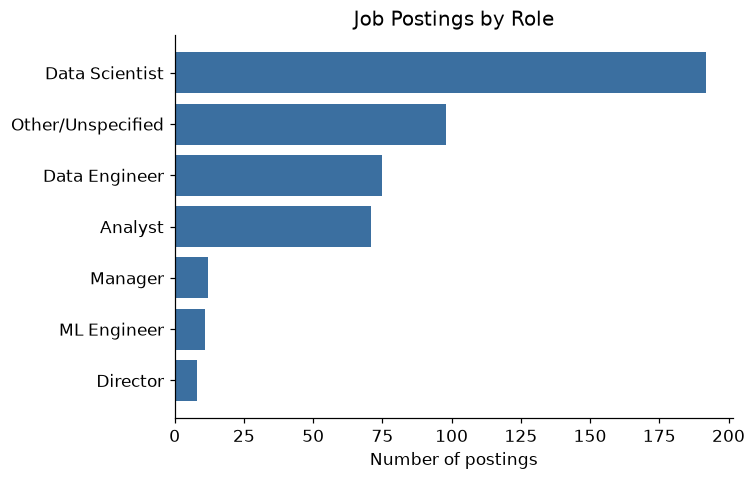

role_clean
Data Scientist       192
Other/Unspecified     98
Data Engineer         75
Analyst               71
Manager               12
ML Engineer           11
Director               8
Name: count, dtype: int64

In [9]:
fig, ax = plt.subplots(figsize=(7,4.5))
vc = clean_df['role_clean'].value_counts()
ax.barh(vc.index[::-1], vc.values[::-1], color='#3b6fa0')
ax.set_title('Job Postings by Role'); ax.set_xlabel('Number of postings')
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/01_top_roles.png'); plt.show()
vc


### 11.2 Skills Analysis

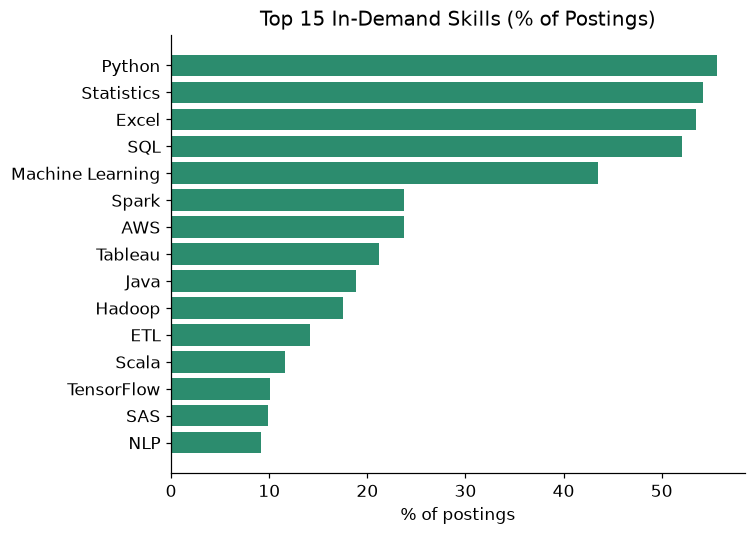

Python              55.7
Statistics          54.2
Excel               53.5
SQL                 52.0
Machine Learning    43.5
Spark               23.8
AWS                 23.8
Tableau             21.2
Java                18.8
Hadoop              17.6
ETL                 14.1
Scala               11.6
TensorFlow          10.1
SAS                  9.9
NLP                  9.2
dtype: float64

In [10]:
pct = (clean_df[skill_cols].sum().sort_values(ascending=False) / len(clean_df) * 100).head(15)
pct.index = [c.replace('skill_','').replace('_',' ') for c in pct.index]
fig, ax = plt.subplots(figsize=(7,5))
ax.barh(pct.index[::-1], pct.values[::-1], color='#2c8c6e')
ax.set_title('Top 15 In-Demand Skills (% of Postings)'); ax.set_xlabel('% of postings')
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/02_top_skills.png'); plt.show()
pct.round(1)


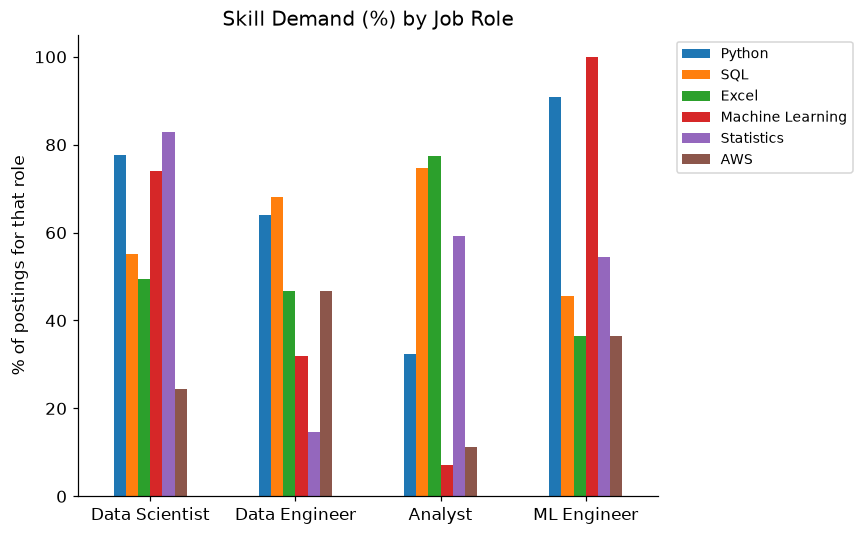

,Data Scientist,Data Engineer,Analyst,ML Engineer
Python,77.6,64.0,32.4,90.9
SQL,55.2,68.0,74.6,45.5
Excel,49.5,46.7,77.5,36.4
Machine Learning,74.0,32.0,7.0,100.0
Statistics,82.8,14.7,59.2,54.5
AWS,24.5,46.7,11.3,36.4


In [11]:
top_skills = ['skill_Python','skill_SQL','skill_Excel','skill_Machine_Learning','skill_Statistics','skill_AWS']
roles = ['Data Scientist','Data Engineer','Analyst','ML Engineer']
mat = pd.DataFrame({r: clean_df.loc[clean_df['role_clean']==r, top_skills].mean()*100 for r in roles})
mat.index = [c.replace('skill_','').replace('_',' ') for c in mat.index]
mat.T.plot(kind='bar', figsize=(8,5))
plt.title('Skill Demand (%) by Job Role'); plt.ylabel('% of postings for that role')
plt.xticks(rotation=0); plt.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=9)
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/03_skills_by_role.png'); plt.show()
mat.round(1)


### 11.3 Location Analysis

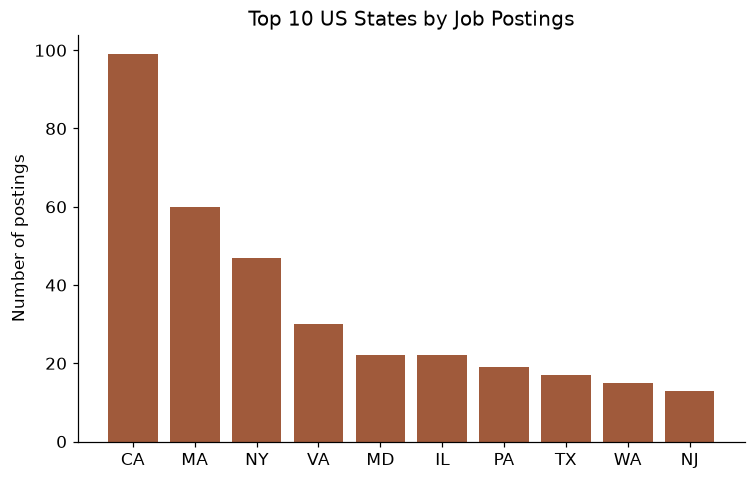

state
CA    99
MA    60
NY    47
VA    30
MD    22
IL    22
PA    19
TX    17
WA    15
NJ    13
Name: count, dtype: int64

In [12]:
vc = clean_df['state'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(7,4.5))
ax.bar(vc.index, vc.values, color='#a05a3b')
ax.set_title('Top 10 US States by Job Postings'); ax.set_ylabel('Number of postings')
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/04_jobs_by_state.png'); plt.show()
vc


### 11.4 Salary Analysis

count       467.0
mean     100979.0
std       37319.0
min       13500.0
25%       76000.0
50%       97500.0
75%      121000.0
max      254000.0
Name: avg_salary_usd, dtype: float64


<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
/var/folders/4j/79twzb_j73vcnzwkh1x38hrh0000gn/T/ipykernel_12942/2782086682.py:5: SyntaxWarning: invalid escape sequence '\$'
  label=f"Median = \${clean_df['avg_salary_usd'].median():,.0f}")


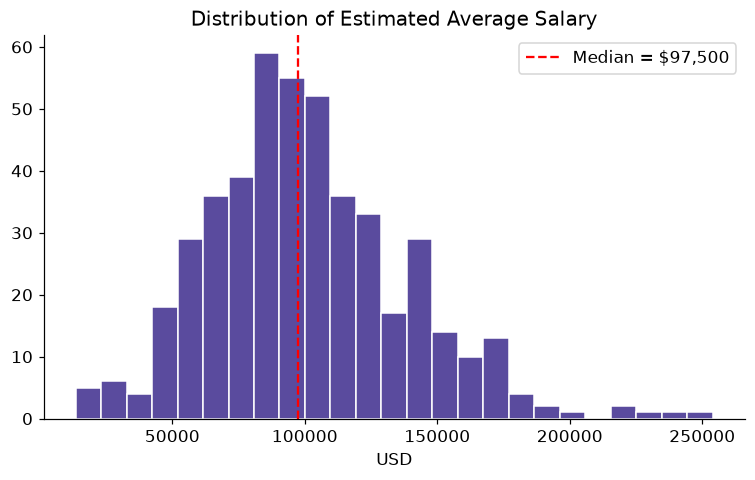

In [13]:
print(clean_df['avg_salary_usd'].describe().round(0))
fig, ax = plt.subplots(figsize=(7,4.5))
ax.hist(clean_df['avg_salary_usd'], bins=25, color='#5a4b9e', edgecolor='white')
ax.axvline(clean_df['avg_salary_usd'].median(), color='red', linestyle='--',
           label=f"Median = \${clean_df['avg_salary_usd'].median():,.0f}")
ax.set_title('Distribution of Estimated Average Salary'); ax.set_xlabel('USD'); ax.legend()
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/05_salary_distribution.png'); plt.show()


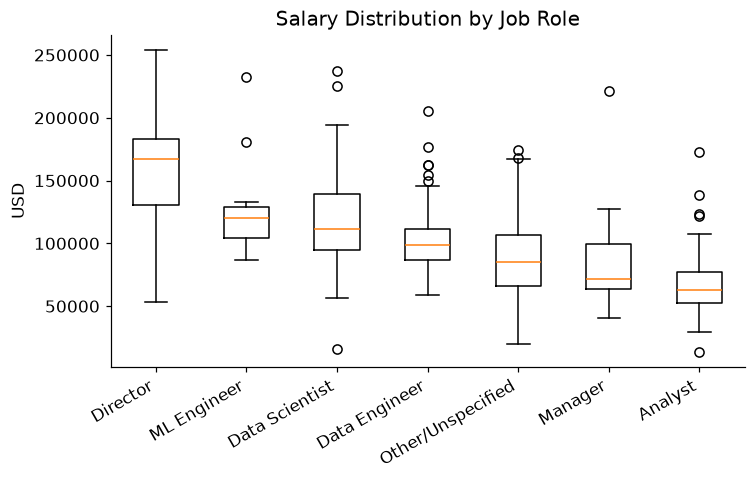

,count,mean,median
role_clean,,,
Director,8,156938.0,166750.0
ML Engineer,11,128045.0,120000.0
Data Scientist,192,115906.0,111250.0
Data Engineer,75,102867.0,98500.0
Manager,12,89792.0,71250.0
Other/Unspecified,98,87781.0,85000.0
Analyst,71,68225.0,62500.0


In [14]:
order = clean_df.groupby('role_clean')['avg_salary_usd'].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(7,4.5))
data = [clean_df.loc[clean_df['role_clean']==r, 'avg_salary_usd'] for r in order]
ax.boxplot(data, tick_labels=order)
plt.xticks(rotation=30, ha='right'); ax.set_ylabel('USD'); ax.set_title('Salary Distribution by Job Role')
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/06_salary_by_role.png'); plt.show()
clean_df.groupby('role_clean')['avg_salary_usd'].agg(['count','mean','median']).sort_values('mean',ascending=False).round(0)


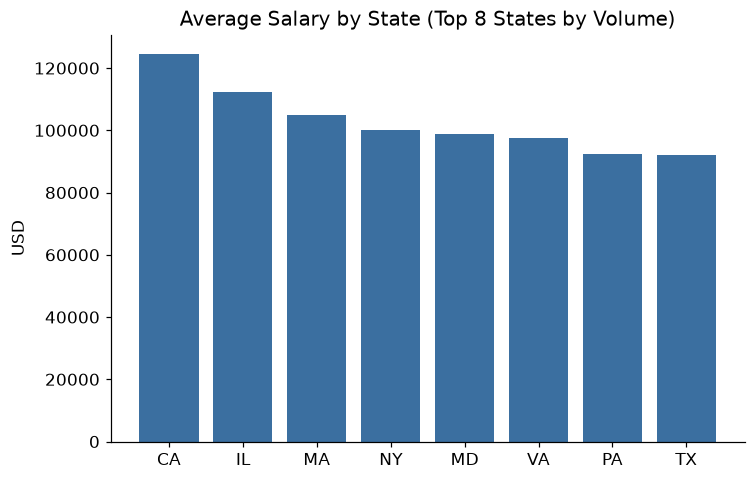

state
CA    124449.0
IL    112295.0
MA    104758.0
NY    100234.0
MD     98955.0
VA     97667.0
PA     92342.0
TX     91971.0
Name: avg_salary_usd, dtype: float64

In [15]:
top_states = clean_df['state'].value_counts().head(8).index
means = clean_df[clean_df['state'].isin(top_states)].groupby('state')['avg_salary_usd'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7,4.5))
ax.bar(means.index, means.values, color='#3b6fa0')
ax.set_title('Average Salary by State (Top 8 States by Volume)'); ax.set_ylabel('USD')
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/07_salary_by_state.png'); plt.show()
means.round(0)


### 11.5 Experience / Seniority Analysis

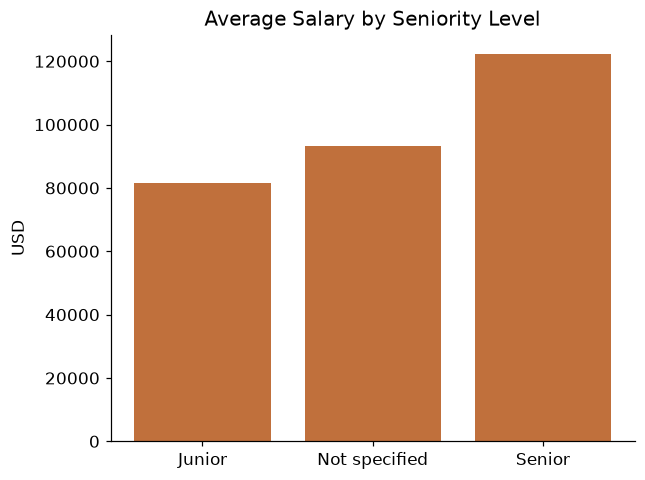

,count,mean
seniority_clean,,
Junior,2,81500.0
Not specified,341,93368.0
Senior,124,122222.0


In [16]:
means = clean_df.groupby('seniority_clean')['avg_salary_usd'].agg(['count','mean']).reindex(['Junior','Not specified','Senior'])
fig, ax = plt.subplots(figsize=(6,4.5))
ax.bar(means.index, means['mean'], color='#c0703c')
ax.set_title('Average Salary by Seniority Level'); ax.set_ylabel('USD')
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/08_salary_by_seniority.png'); plt.show()
means.round(0)


### 11.6 Work-Mode Analysis

**Not performed.** As established in Section 6 (Dataset Inspection), this dataset does not include a
remote/hybrid/on-site field. Per the project's own "do not fabricate results" requirement, this analysis is
skipped rather than approximated.


### 11.7 Industry Distribution

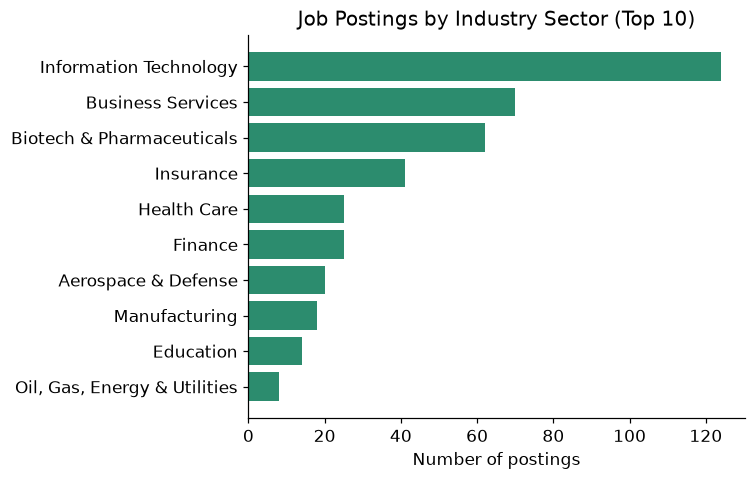

sector
Information Technology          124
Business Services                70
Biotech & Pharmaceuticals        62
Insurance                        41
Health Care                      25
Finance                          25
Aerospace & Defense              20
Manufacturing                    18
Education                        14
Oil, Gas, Energy & Utilities      8
Name: count, dtype: int64

In [17]:
vc = clean_df['sector'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(7,4.5))
ax.barh(vc.index[::-1], vc.values[::-1], color='#2c8c6e')
ax.set_title('Job Postings by Industry Sector (Top 10)'); ax.set_xlabel('Number of postings')
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/09_industry.png'); plt.show()
vc


## 12. Statistical Analysis

All tests below describe **association**, not causation — this is observational job-posting data, not a
controlled experiment.


In [18]:
# Does seniority relate to salary?
groups = [clean_df.loc[clean_df['seniority_clean']==g,'avg_salary_usd'] for g in ['Junior','Not specified','Senior']]
f, p = stats.f_oneway(*[g for g in groups if len(g) > 1])
print(f"ANOVA (salary ~ seniority): F={f:.2f}, p={p:.5f}")

sen_map = {'Junior':0,'Not specified':1,'Senior':2}
clean_df['seniority_ord'] = clean_df['seniority_clean'].map(sen_map)
r, p = stats.pearsonr(clean_df['seniority_ord'], clean_df['avg_salary_usd'])
print(f"Pearson r (seniority rank vs salary) = {r:.3f}, p={p:.5f}")


ANOVA (salary ~ seniority): F=30.99, p=0.00000
Pearson r (seniority rank vs salary) = 0.342, p=0.00000


In [19]:
# Do specific skills associate with higher pay?
for skill in ['skill_Machine_Learning','skill_Python','skill_Statistics','skill_Tableau','skill_Excel']:
    a = clean_df.loc[clean_df[skill]==1,'avg_salary_usd']; b = clean_df.loc[clean_df[skill]==0,'avg_salary_usd']
    t, p = stats.ttest_ind(a, b, equal_var=False)
    print(f"{skill:28s} n={len(a):3d}  mean_with=\${a.mean():>9,.0f}  mean_without=\${b.mean():>9,.0f}  t={t:6.2f}  p={p:.4f}")


skill_Machine_Learning       n=203  mean_with=\$  116,589  mean_without=\$   88,975  t=  8.56  p=0.0000
skill_Python                 n=260  mean_with=\$  110,410  mean_without=\$   89,133  t=  6.37  p=0.0000
skill_Statistics             n=253  mean_with=\$  109,014  mean_without=\$   91,479  t=  5.25  p=0.0000
skill_Tableau                n= 99  mean_with=\$   95,126  mean_without=\$  102,553  t= -1.92  p=0.0564
skill_Excel                  n=250  mean_with=\$   98,678  mean_without=\$  103,629  t= -1.44  p=0.1517


<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
/var/folders/4j/79twzb_j73vcnzwkh1x38hrh0000gn/T/ipykernel_12942/879140211.py:5: SyntaxWarning: invalid escape sequence '\$'
  print(f"{skill:28s} n={len(a):3d}  mean_with=\${a.mean():>9,.0f}  mean_without=\${b.mean():>9,.0f}  t={t:6.2f}  p={p:.4f}")
/var/folders/4j/79twzb_j73vcnzwkh1x38hrh0000gn/T/ipykernel_12942/879140211.py:5: SyntaxWarning: invalid escape sequence '\$'
  print(f"{skill:28s} n={len(a):3d}  mean_with=\${a.mean():>9,.0f}  mean_without=\${b.mean():>9,.0f}  t={t:6.2f}  p={p:.4f}")


In [20]:
# Does location relate to salary?
top_states = clean_df['state'].value_counts().head(8).index
groups = [clean_df.loc[clean_df['state']==s,'avg_salary_usd'] for s in top_states]
f, p = stats.f_oneway(*groups)
print(f"ANOVA (salary ~ state) across top-8 states by volume: F={f:.2f}, p={p:.5f}")

sub = clean_df.dropna(subset=['company_rating'])
r, p = stats.pearsonr(sub['company_rating'], sub['avg_salary_usd'])
print(f"Pearson r (company rating vs salary) = {r:.3f}, p={p:.4f}, n={len(sub)}")


ANOVA (salary ~ state) across top-8 states by volume: F=5.05, p=0.00002
Pearson r (company rating vs salary) = 0.115, p=0.0139, n=460


## 13. AI/ML Component — Salary Prediction

**Objective:** predict `avg_salary_usd` from job role, seniority, state, company size, and extracted skills, as a
genuinely useful Data-Analytics-with-AI addition (Option B from the internship brief), and report its accuracy
and limitations honestly rather than presenting it as a production-ready tool.

**Features used:** `role_clean`, `seniority_clean`, `state`, `company_size_clean` (one-hot encoded) + all 26
binary skill flags.
**Models compared:** Linear Regression (simple baseline) and Random Forest Regressor (handles non-linear
interactions between role/seniority/skills).
**Evaluation:** 80/20 train-test split, Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), R².


In [21]:
cat_features = ['role_clean','seniority_clean','state','company_size_clean']
num_features = skill_cols

X = clean_df[cat_features + num_features].copy()
y = clean_df['avg_salary_usd']

pre = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)], remainder='passthrough')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

results = {}
for name, model in [('Linear Regression', LinearRegression()),
                     ('Random Forest', RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42))]:
    pipe = Pipeline([('pre', pre), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2 = r2_score(y_test, preds)
    results[name] = (mae, rmse, r2)
    print(f"{name:18s}  MAE=\${mae:>8,.0f}  RMSE=\${rmse:>8,.0f}  R2={r2:.3f}")

baseline_mae = mean_absolute_error(y_test, np.full_like(y_test, y_train.mean(), dtype=float))
print(f"{'Baseline (mean)':18s}  MAE=\${baseline_mae:>8,.0f}   <- always predicting the training-set average salary")


<>:20: SyntaxWarning: invalid escape sequence '\$'
<>:20: SyntaxWarning: invalid escape sequence '\$'
<>:23: SyntaxWarning: invalid escape sequence '\$'
<>:20: SyntaxWarning: invalid escape sequence '\$'
<>:20: SyntaxWarning: invalid escape sequence '\$'
<>:23: SyntaxWarning: invalid escape sequence '\$'
/var/folders/4j/79twzb_j73vcnzwkh1x38hrh0000gn/T/ipykernel_12942/2153759499.py:20: SyntaxWarning: invalid escape sequence '\$'
  print(f"{name:18s}  MAE=\${mae:>8,.0f}  RMSE=\${rmse:>8,.0f}  R2={r2:.3f}")
/var/folders/4j/79twzb_j73vcnzwkh1x38hrh0000gn/T/ipykernel_12942/2153759499.py:20: SyntaxWarning: invalid escape sequence '\$'
  print(f"{name:18s}  MAE=\${mae:>8,.0f}  RMSE=\${rmse:>8,.0f}  R2={r2:.3f}")
/var/folders/4j/79twzb_j73vcnzwkh1x38hrh0000gn/T/ipykernel_12942/2153759499.py:23: SyntaxWarning: invalid escape sequence '\$'
  print(f"{'Baseline (mean)':18s}  MAE=\${baseline_mae:>8,.0f}   <- always predicting the training-set average salary")


Linear Regression   MAE=\$  22,771  RMSE=\$  31,373  R2=0.405
Random Forest       MAE=\$  21,815  RMSE=\$  30,510  R2=0.437
Baseline (mean)     MAE=\$  31,291   <- always predicting the training-set average salary


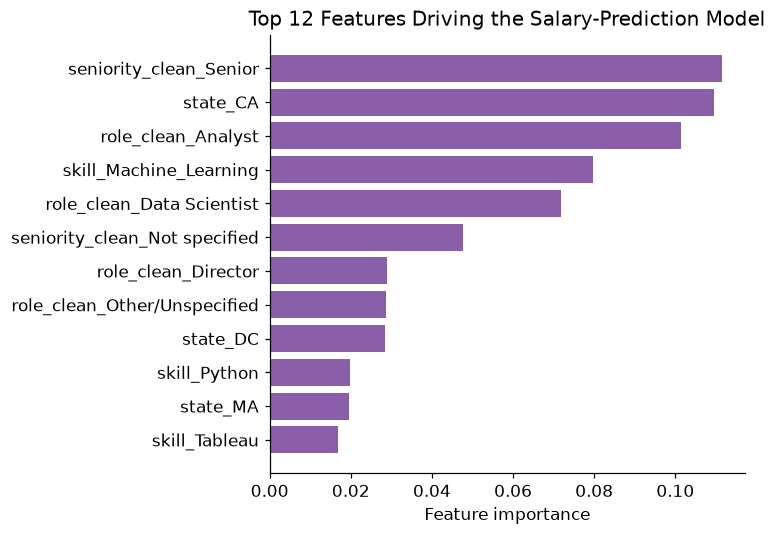

seniority_clean_Senior           0.112
state_CA                         0.109
role_clean_Analyst               0.101
skill_Machine_Learning           0.080
role_clean_Data Scientist        0.072
seniority_clean_Not specified    0.048
role_clean_Director              0.029
role_clean_Other/Unspecified     0.029
state_DC                         0.028
skill_Python                     0.020
state_MA                         0.020
skill_Tableau                    0.017
dtype: float64

In [22]:
# Feature importance (Random Forest) - which features drive the model's predictions
best_pipe = Pipeline([('pre', pre), ('model', RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42))])
best_pipe.fit(X_train, y_train)
feat_names = best_pipe.named_steps['pre'].get_feature_names_out()
importances = best_pipe.named_steps['model'].feature_importances_
imp = pd.Series(importances, index=[f.split('__')[-1] for f in feat_names]).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(7,5))
ax.barh(imp.index[::-1], imp.values[::-1], color='#8a5ea8')
ax.set_title('Top 12 Features Driving the Salary-Prediction Model'); ax.set_xlabel('Feature importance')
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/10_ml_feature_importance.png'); plt.show()
imp.round(3)


**Results & interpretation:** the Random Forest model (MAE ≈ \$21,800, R² ≈ 0.44) meaningfully outperforms a
naive baseline that always predicts the average salary (MAE ≈ \$31,300), showing that role, seniority, location
and skills together do carry real predictive signal for salary in this dataset. Seniority, being in California,
being an Analyst (negatively) or Data Scientist (positively), and mentioning Machine Learning are the strongest
individual drivers.

**Limitations of this model (stated honestly, not hidden):**
- R² ≈ 0.44 means the majority of salary variation is still unexplained by these features — this is a modest,
  exploratory model, not a precise salary calculator.
- Trained on only 373 postings (80% of 467) — a small sample for 30+ one-hot-encoded features, so the model can
  overfit to quirks of this particular scrape.
- The dataset predates 2021+ remote-work and inflation shifts, so predictions should not be used for 2024+
  salary benchmarking.
- This model is illustrative of the AI component the internship brief allows, not a production tool.


## 14. Key Findings

All figures below are computed directly above, from the actual cleaned dataset (467 postings) — none are assumed.

1. **Duplicates were a major data-quality issue:** 275 of 742 raw postings (37%) were exact duplicate scrapes of the same live listing, removed before any analysis.
2. **Python, Statistics, Excel, SQL and Machine Learning are the five most in-demand skills** (55.7%, 54.2%, 53.5%, 52.0%, 43.5% of postings respectively).
3. **Skill demand differs sharply by role:** Analysts lean on Excel/SQL/Tableau; Data Engineers on SQL/Spark/Java/AWS; Data Scientists on Statistics/Python/ML; ML Engineers almost universally need Machine Learning + Python.
4. **Salary rises significantly with seniority** (ANOVA F=30.99, p<0.0001): Senior-tagged postings average \$122,222 vs. \$93,368 for unspecified seniority.
5. **Salary varies significantly by U.S. state** (ANOVA F=5.05, p<0.0001), with California ($124,449 avg), Illinois and Massachusetts the highest-paying among high-volume states.
6. **Machine Learning and Python carry a statistically significant salary premium** (+\$27,613 and +\$21,277 respectively, t-test p<0.0001); Excel and Tableau show a small, non-significant negative association, most plausibly reflecting their concentration in the lower-paid Analyst role rather than the tools' intrinsic value.
7. **A Random Forest salary-prediction model** built from role/seniority/state/skills beats a naive average-salary baseline (MAE \$21,815 vs. \$31,291; R²=0.44), confirming these features carry genuine predictive signal — while still leaving most variance unexplained.


## 15. Recommendations

- **Students:** prioritize Python, SQL, and core statistics — each appears in roughly half of all postings in this dataset, well ahead of any single specialized tool.
- **Educational institutions:** teach SQL and Python together rather than as alternatives — most postings that need either one also need the other.
- **Job seekers targeting Data Scientist roles:** expect Statistics, Python and Machine Learning to be evaluated together (each appears in 74-83% of Data Scientist postings in this dataset).
- **Employers:** 73% of postings in this dataset state no seniority level at all — clearer leveling in job titles could reduce pay-expectation mismatches during hiring.

These recommendations describe patterns in this specific 467-posting, U.S., 2020 dataset and are not guarantees for any individual's career outcome.


## 16. Limitations

- Scope: U.S.-only, data-science-related postings, single 2020 snapshot — not global, not all industries, not a time series.
- No remote/hybrid/on-site field exists in the source data (see Section 6); this analysis was correctly skipped rather than fabricated.
- Seniority is inferred from job-title keywords only, missing for 73% of postings.
- Skill flags are keyword/regex-based and can occasionally miss an implied skill or match an unrelated context.
- Skill-vs-salary comparisons are associational, not causal; role and seniority likely confound the raw comparisons.
- The salary-prediction model (Section 13) explains under half of salary variance (R²≈0.44) and was trained on only 373 rows — it is exploratory, not production-grade.


## 17. Conclusion

Within the scope of 467 cleaned U.S. data-science job postings from 2020, this project identified clear,
statistically supported patterns in skill demand, role-specific skill requirements, and salary by seniority and
location, and built a modest but genuinely predictive salary model as its AI component. The project also
explicitly documents what this single, U.S.-only, 2020 dataset cannot support (e.g. work-mode analysis, global
generalization), in line with the internship's requirement to avoid fabricated or unsupported conclusions.


## References

1. Jee, K. (PlayingNumbers). *ds_salary_proj* [Dataset & code]. GitHub. https://github.com/PlayingNumbers/ds_salary_proj
2. Glassdoor.com — original source of the scraped job postings.
3. pandas, NumPy, Matplotlib, SciPy, scikit-learn — official documentation.
